This notebook is used to run full graph discovery on Rossler and stochastic ENSO with the XRO package.

__NOTE__: Before starting, make sure to follow the instruction and download the timeseries data from https://kausable.github.io/CausalDynamics/README.html. The baseline results can be found in the same `CausalDynamics` data repository. 

References:
- https://github.com/senclimate/XRO
- https://www.nature.com/articles/s41586-024-07534-6

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import copy
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import torch

from kausal import Graph
from kausal.koopman import Kausal
from kausal.observables import RandomFourierFeatures, TimeDelayFeatures, MLPFeatures
from kausal.utils import score

import warnings
warnings.filterwarnings('ignore')


In [ ]:
## CHANGE THIS TO YOUR OWN PATH
dataset_path = Path('CausalDynamics') 

# Simple (N=3) example

In [3]:
# Load data
DATA_PATH = dataset_path / 'data/simple/noise=0.00_confounder=False/data'
ds = xr.open_dataset(DATA_PATH / 'Rossler_N10_T1000.nc')
adj_matrix = ds['adjacency_matrix'].to_numpy()
timeseries = ds['time_series'].to_numpy().transpose(1, 2, 0)[:, :, None, :] # (num_system, num_nodes, num_vars, num_steps)


In [4]:
%%time
# Kausal (Graph discovery mode)
hidden_channels = [8, 16]
lr = 1e-3
epochs = 1
n_train = int(0.8 * timeseries.shape[-1])

kausal_adj_matrix = []

for x in timeseries[-1:]:
    graph_model = Graph(
        marginal_observable = MLPFeatures(in_channels=1, hidden_channels=hidden_channels, out_channels=1),
        joint_observable = MLPFeatures(in_channels=2, hidden_channels=hidden_channels, out_channels=1)
    )
    
    graph_model.infer(
        X = torch.tensor(x),
        time_shift = 100,
        fit_kwargs = {'n_train': n_train, 'epochs': epochs, 'lr': lr, 'batch_size': n_train},
        bootstrap_kwargs = {'bootstrap_ratio': 0.9, 'bootstrap_nums': 30}
    )

    
    kausal_adj_matrix.append(
        copy.deepcopy(
            graph_model.get_adjacency(p_crit=0.05)
        )
    )

# Scoring
score(
    preds= np.array(kausal_adj_matrix),
    labs= adj_matrix,
    name='Kausal'
)

CPU times: user 27.1 s, sys: 571 ms, total: 27.6 s
Wall time: 2.81 s


,Kausal
Metric,
Joint AUROC,0.666667
Individual AUROC,0.666667
Null AUROC,0.500000
Joint AUPRC,0.755556
Individual AUPRC,0.755556
Null AUPRC,0.666667
Joint SHD,3.000000


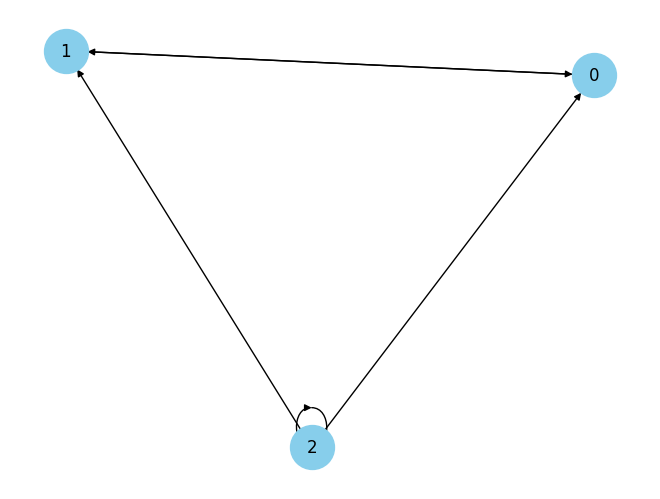

In [5]:
graph_model.plot_adjacency()

In [6]:
graph_model.print_result()

          mean       std      pval
0->0 -0.020747  0.000819  1.000000
0->1  4.156826  0.083961  0.032258
0->2 -0.638335  0.006743  1.000000
1->0  3.476890  0.039235  0.032258
1->1 -0.017300  0.004321  1.000000
1->2  0.002842  0.024826  0.193548
2->0  0.291276  0.009050  0.032258
2->1  0.700255  0.019356  0.032258
2->2  0.114247  0.000788  0.032258


In [7]:
adj_matrix

array([[0, 1, 1],
       [1, 1, 0],
       [1, 0, 1]])

In [8]:
graph_model.get_adjacency()

tensor([[0, 1, 0],
        [1, 0, 0],
        [1, 1, 1]], dtype=torch.int32)

# Climate (N=10) example

In [9]:
# Load data
DATA_PATH = dataset_path / 'data/climate/coupled_enso_modes/data'
ds = xr.open_dataset(DATA_PATH / 'AO_N10_T1000.nc')
adj_matrix = ds['adjacency_matrix'].to_numpy()
timeseries = ds['time_series'].to_numpy().transpose(1, 2, 3, 0) # (num_system, num_nodes, num_vars, num_steps)


In [10]:
%%time
# Kausal (Graph discovery mode)
hidden_channels = [8, 16]
lr = 1e-3
epochs = 1
n_train = int(0.8 * timeseries.shape[-1])

kausal_adj_matrix = []

for x in timeseries[-1:]:
    graph_model = Graph(
        marginal_observable = MLPFeatures(in_channels=1, hidden_channels=hidden_channels, out_channels=1),
        joint_observable = MLPFeatures(in_channels=2, hidden_channels=hidden_channels, out_channels=1)
    )
    
    graph_model.infer(
        X = torch.tensor(x),
        time_shift = 100,
        fit_kwargs = {'n_train': n_train, 'epochs': epochs, 'lr': lr, 'batch_size': n_train},
        bootstrap_kwargs = {'bootstrap_ratio': 0.9, 'bootstrap_nums': 30}
    )

    
    kausal_adj_matrix.append(
        copy.deepcopy(
            graph_model.get_adjacency(p_crit=0.05)
        )
    )

# Scoring
score(
    preds= np.array(kausal_adj_matrix),
    labs= adj_matrix,
    name='Kausal'
)


CPU times: user 4min 41s, sys: 225 ms, total: 4min 42s
Wall time: 11.5 s


,Kausal
Metric,
Joint AUROC,0.640476
Individual AUROC,0.640476
Null AUROC,0.500000
Joint AUPRC,0.764991
Individual AUPRC,0.764991
Null AUPRC,0.700000
Joint SHD,25.000000


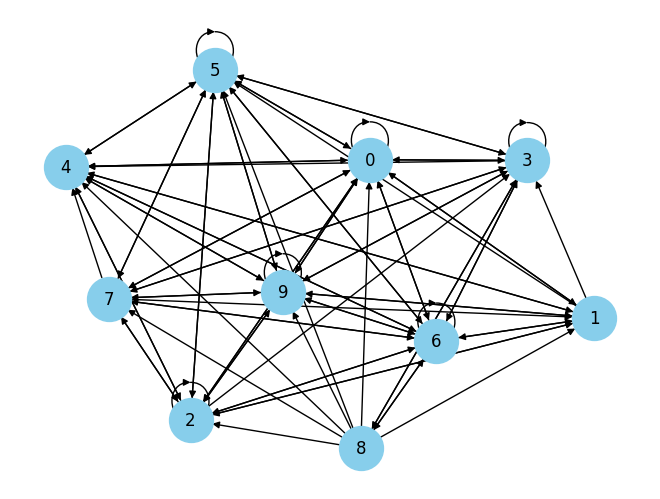

In [11]:
graph_model.plot_adjacency()

In [12]:
graph_model.print_result()

          mean       std      pval
0->0  0.003013  0.000520  0.032258
0->1  0.311090  0.122325  0.032258
0->2  0.004729  0.000202  0.032258
0->3  0.000710  0.000103  0.032258
0->4  0.000379  0.000066  0.032258
...        ...       ...       ...
9->5  0.000626  0.000153  0.032258
9->6  0.073198  0.026389  0.032258
9->7  0.051610  0.008812  0.032258
9->8 -0.190404  0.010686  1.000000
9->9  0.000394  0.000217  0.032258

[100 rows x 3 columns]


In [13]:
adj_matrix

array([[1., 1., 1., 1., 1., 1., 1., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 0., 0., 0.]])

In [14]:
graph_model.get_adjacency()

tensor([[1, 1, 1, 1, 1, 1, 1, 1, 0, 1],
        [1, 0, 1, 1, 1, 1, 1, 0, 0, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 0, 1],
        [1, 0, 0, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 0, 0, 1, 1, 0, 0, 1],
        [1, 0, 1, 1, 1, 1, 1, 1, 0, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 0, 0, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 0, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 0, 1]], dtype=torch.int32)